## Step - 1
___

# Business problem
---
Predict which customers will leave a service (bank / telecom / SaaS)

---

## Step-2 Import all necessary libraries  

In [47]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder

## Step-3 Load dataset
---

In [2]:
df = pd.read_csv("customer_churn_dataset.csv")



## Step - 4 Basic Data Overview 
___

In [3]:
df.head()

,tenure,monthly_charges,total_charges,support_calls,contract_type_score,payment_delay,internet_usage,complaints,churn
0,1.163983,-0.901654,-1.165771,1.460129,0.276193,-1.332095,-0.737489,-0.621535,0
1,-1.663195,2.135120,-1.938391,0.949322,0.440862,0.383097,-0.407220,-0.829364,0
2,-0.051788,1.469270,-0.223656,-0.242955,1.314758,-2.074971,-0.614252,-0.746351,1
3,-0.967457,0.946308,-0.891655,2.613858,1.250459,-0.428566,-0.340471,-2.424708,0
4,0.553730,-0.342017,-1.087678,-0.887323,2.534107,-1.905329,1.237635,-1.010412,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tenure               2000 non-null   float64
 1   monthly_charges      2000 non-null   float64
 2   total_charges        2000 non-null   float64
 3   support_calls        2000 non-null   float64
 4   contract_type_score  2000 non-null   float64
 5   payment_delay        2000 non-null   float64
 6   internet_usage       2000 non-null   float64
 7   complaints           2000 non-null   float64
 8   churn                2000 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 140.8 KB


In [5]:
df.describe()

,tenure,monthly_charges,total_charges,support_calls,contract_type_score,payment_delay,internet_usage,complaints,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000
mean,-0.473116,0.408420,-0.009520,0.569690,0.586659,0.031235,0.175302,-0.605379,0.40000
std,1.341539,1.530805,1.014015,1.655120,1.500095,1.587433,1.562407,1.307508,0.49002
min,-3.823901,-5.248759,-3.757435,-4.716066,-6.153423,-6.197663,-4.964580,-5.640400,0.00000
25%,-1.448372,-0.494069,-0.690149,-0.513058,-0.202685,-1.091722,-0.822700,-1.465292,0.00000
50%,-0.541302,0.564537,-0.003037,0.583363,0.737485,0.061931,0.180768,-0.688726,0.00000
75%,0.419446,1.465261,0.672307,1.694549,1.592093,1.196401,1.195619,0.438830,1.00000
max,4.857274,4.715561,3.103384,6.137377,6.358007,4.703177,5.953586,4.421027,1.00000


In [6]:
df.size

18000

In [7]:
df.shape

(2000, 9)

In [8]:
df.columns

Index(['tenure', 'monthly_charges', 'total_charges', 'support_calls',
       'contract_type_score', 'payment_delay', 'internet_usage', 'complaints',
       'churn'],
      dtype='object')

## Step - 5 EDA (EXPLORATORY DATA ANALYSIS) + Visualization
___

In [9]:
df.head(2)

,tenure,monthly_charges,total_charges,support_calls,contract_type_score,payment_delay,internet_usage,complaints,churn
0,1.163983,-0.901654,-1.165771,1.460129,0.276193,-1.332095,-0.737489,-0.621535,0
1,-1.663195,2.135120,-1.938391,0.949322,0.440862,0.383097,-0.407220,-0.829364,0


In [10]:
df.isna().sum() # no null values

tenure                 0
monthly_charges        0
total_charges          0
support_calls          0
contract_type_score    0
payment_delay          0
internet_usage         0
complaints             0
churn                  0
dtype: int64

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,2000.0,-0.473116,1.341539,-3.823901,-1.448372,-0.541302,0.419446,4.857274
monthly_charges,2000.0,0.408420,1.530805,-5.248759,-0.494069,0.564537,1.465261,4.715561
total_charges,2000.0,-0.009520,1.014015,-3.757435,-0.690149,-0.003037,0.672307,3.103384
support_calls,2000.0,0.569690,1.655120,-4.716066,-0.513058,0.583363,1.694549,6.137377
contract_type_score,2000.0,0.586659,1.500095,-6.153423,-0.202685,0.737485,1.592093,6.358007
payment_delay,2000.0,0.031235,1.587433,-6.197663,-1.091722,0.061931,1.196401,4.703177
internet_usage,2000.0,0.175302,1.562407,-4.964580,-0.822700,0.180768,1.195619,5.953586
complaints,2000.0,-0.605379,1.307508,-5.640400,-1.465292,-0.688726,0.438830,4.421027
churn,2000.0,0.400000,0.490020,0.000000,0.000000,0.000000,1.000000,1.000000


Text(0.5, 1.0, '0 = No , 1 = Yes')

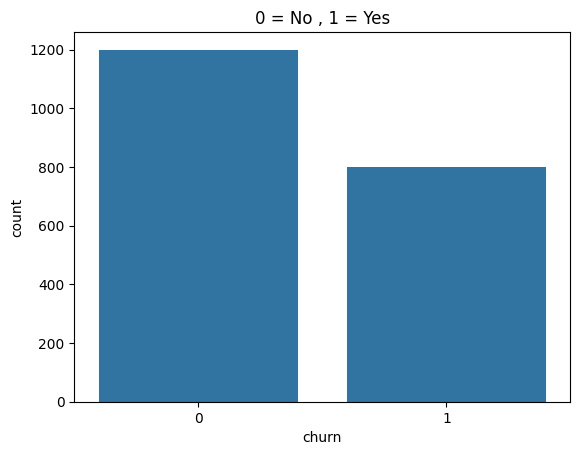

In [12]:
sns.countplot(data=df, x="churn")
plt.title("0 = No , 1 = Yes")

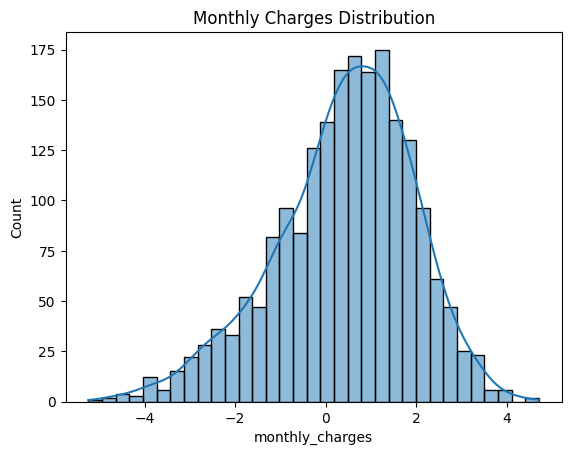

In [13]:
sns.histplot(df["monthly_charges"], kde=True)  # Month;y charges distribution
plt.title("Monthly Charges Distribution")
plt.show()

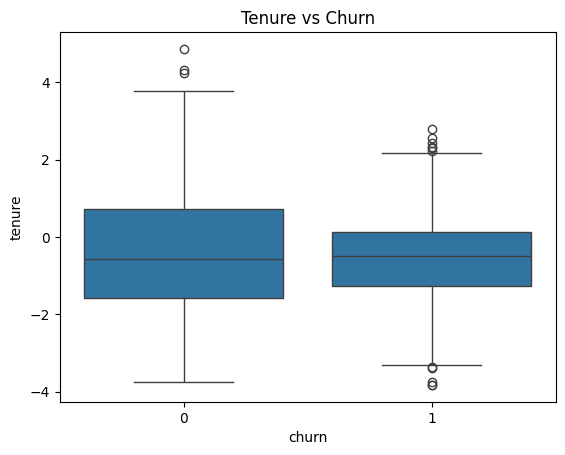

In [14]:
sns.boxplot(x="churn", y="tenure", data=df) 
plt.title("Tenure vs Churn")
plt.show()

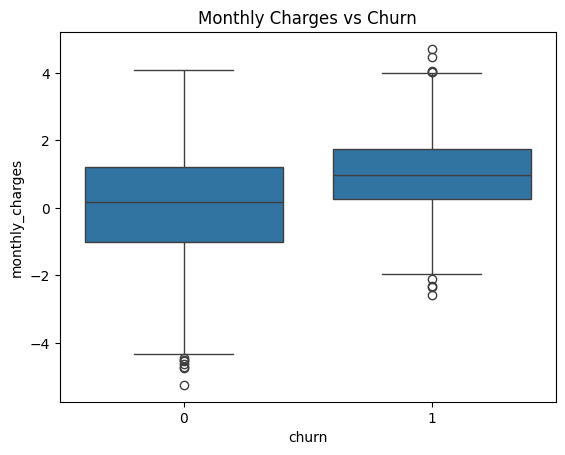

In [15]:
sns.boxplot(x="churn", y="monthly_charges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

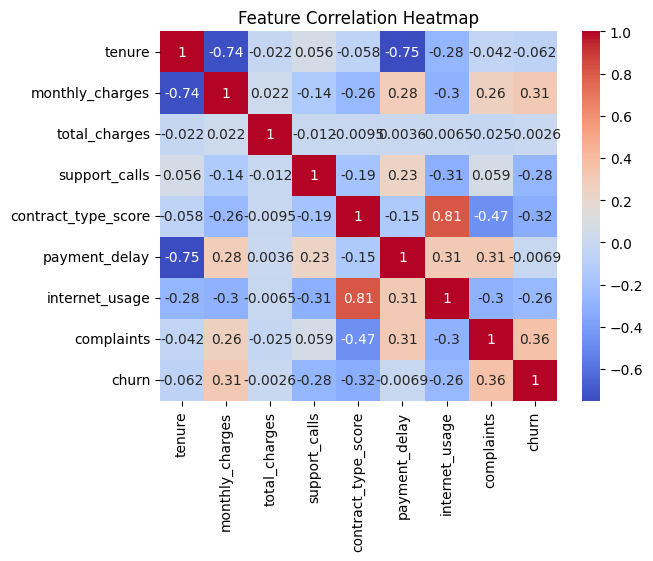

In [16]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

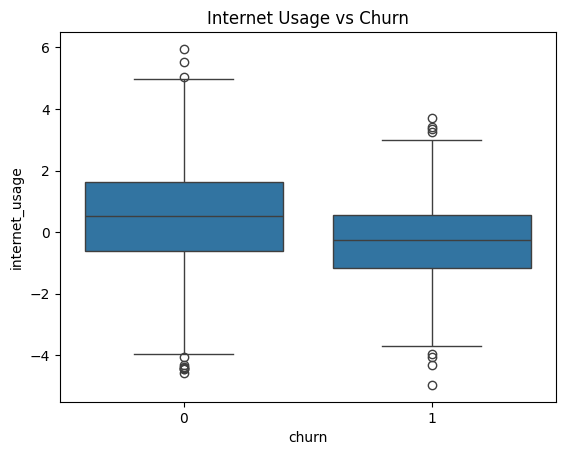

In [17]:
sns.boxplot(x="churn", y="internet_usage", data=df)
plt.title("Internet Usage vs Churn")
plt.show()

## Step - 6 Feature Engineering
___

In [18]:
df["total_charges"] = pd.to_numeric(df["total_charges"], errors="coerce")

In [19]:
df["total_charges"].fillna(df["total_charges"].median(), inplace=True)

In [20]:
df["avg_monthly_spend"] = df["total_charges"] / (df["tenure"] + 1)

In [21]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 6, 12, 24, 48, 100],
    labels=["0-6m", "6-12m", "1-2y", "2-4y", "4y+"]
)

In [22]:
df["complaint_rate"] = df["complaints"] / (df["support_calls"] + 1) # complaint intensity

In [23]:
df["service_stress"] = (
    df["support_calls"] +
    df["payment_delay"] +
    df["complaints"]
)

In [24]:
df["charge_pressure"] = df["monthly_charges"] / (df["internet_usage"] + 1)

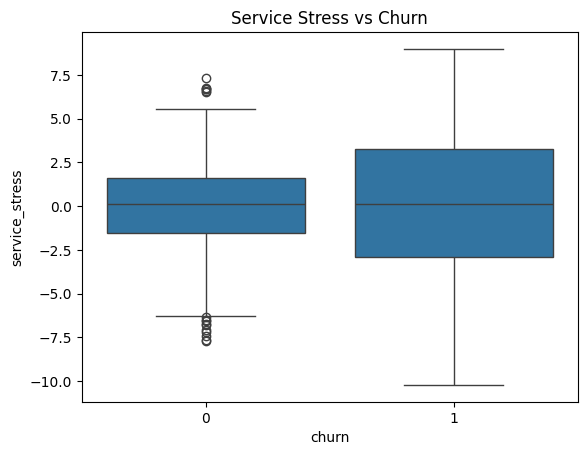

In [25]:
sns.boxplot(x="churn", y="service_stress", data=df)  # churn vs service
plt.title("Service Stress vs Churn")
plt.show()

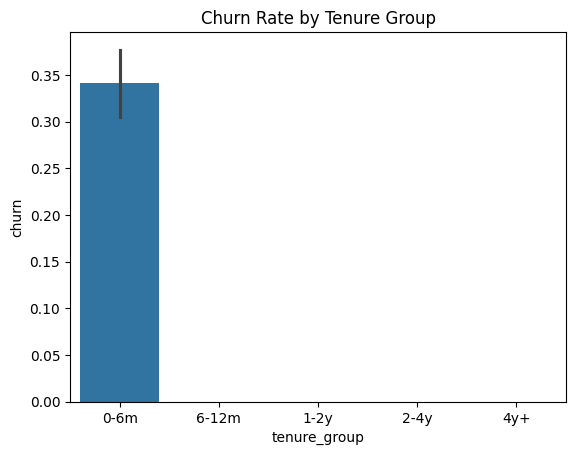

In [26]:
sns.barplot(x="tenure_group", y="churn", data=df)  # by tenure Group
plt.title("Churn Rate by Tenure Group")
plt.show()

* avg_monthly_spend
* tenure_group
* complaint_rate
* service_stress
* charge_pressure
* high_risk

## Step - 7 Model training
___

In [27]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [28]:
df["tenure_group"] = df["tenure_group"].astype(str)

le = LabelEncoder()
df["tenure_group"] = le.fit_transform(df["tenure_group"])

In [29]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)    # logistic regression
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.785

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.79      0.81       240
           1       0.71      0.78      0.74       160

    accuracy                           0.79       400
   macro avg       0.78      0.78      0.78       400
weighted avg       0.79      0.79      0.79       400



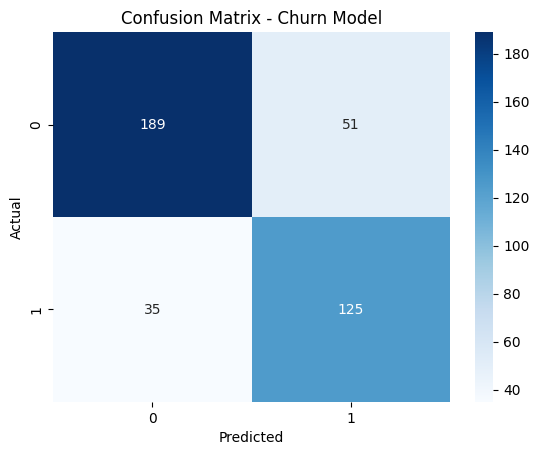

In [41]:

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Churn Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [35]:
pip install xgboost  


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [36]:
from xgboost import XGBClassifier

In [37]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [38]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [42]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

Accuracy: 0.785

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.79      0.81       240
           1       0.71      0.78      0.74       160

    accuracy                           0.79       400
   macro avg       0.78      0.78      0.78       400
weighted avg       0.79      0.79      0.79       400

ROC-AUC Score: 0.8403906250000002


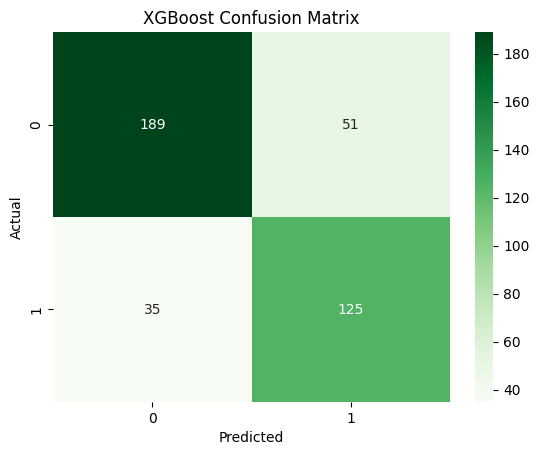

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [44]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
})

importance = importance.sort_values(by="importance", ascending=False)
print(importance)

                feature  importance
10       complaint_rate    0.257451
3         support_calls    0.113608
7            complaints    0.100826
1       monthly_charges    0.096789
11       service_stress    0.087012
4   contract_type_score    0.072654
5         payment_delay    0.071546
0                tenure    0.065381
6        internet_usage    0.055806
12      charge_pressure    0.033233
2         total_charges    0.023122
8     avg_monthly_spend    0.022570
9          tenure_group    0.000000


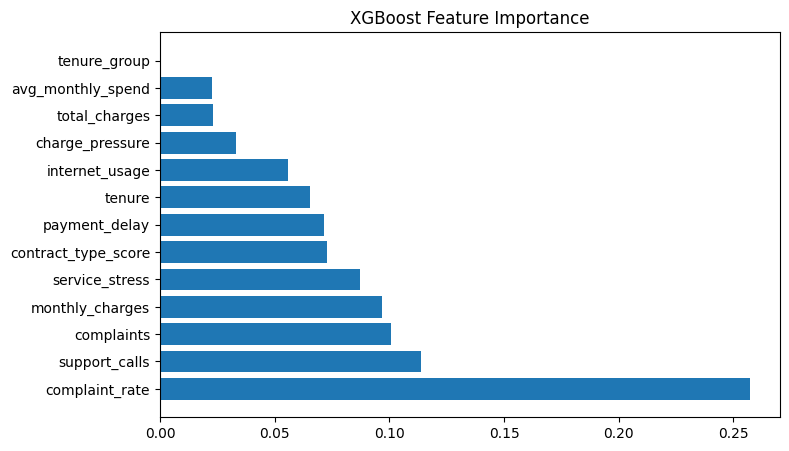

In [46]:
plt.figure(figsize=(8,5))
plt.barh(importance["feature"], importance["importance"])
plt.title("XGBoost Feature Importance")
plt.show()

XGBoost was used to capture non-linear relationships between customer behavior variables and churn. It significantly improved predictive performance compared to baseline models

___
